In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
import colorsys

import map_generation

map_radius = 30
altitude_min = -5000
altitude_max = 5000

def get_tile_color(tile, basin=False):
    if basin and tile.basin != -1:
        r, g, b = colorsys.hsv_to_rgb((0.05*tile.basin)%1.0, 1.0, 1.0)
        col = tile.basin%255
        return f'#{int(col):02x}{int(col):02x}{int(col):02x}'
    if tile.altitude < 0:
        if tile.altitude > -750:
            return '#2b99f9'
        else:
            return "#2d3895"
    else:
        norm_altitude = np.interp(tile.altitude, [0, 5000], [0.25, 1.0])
        return plt.cm.terrain(norm_altitude)


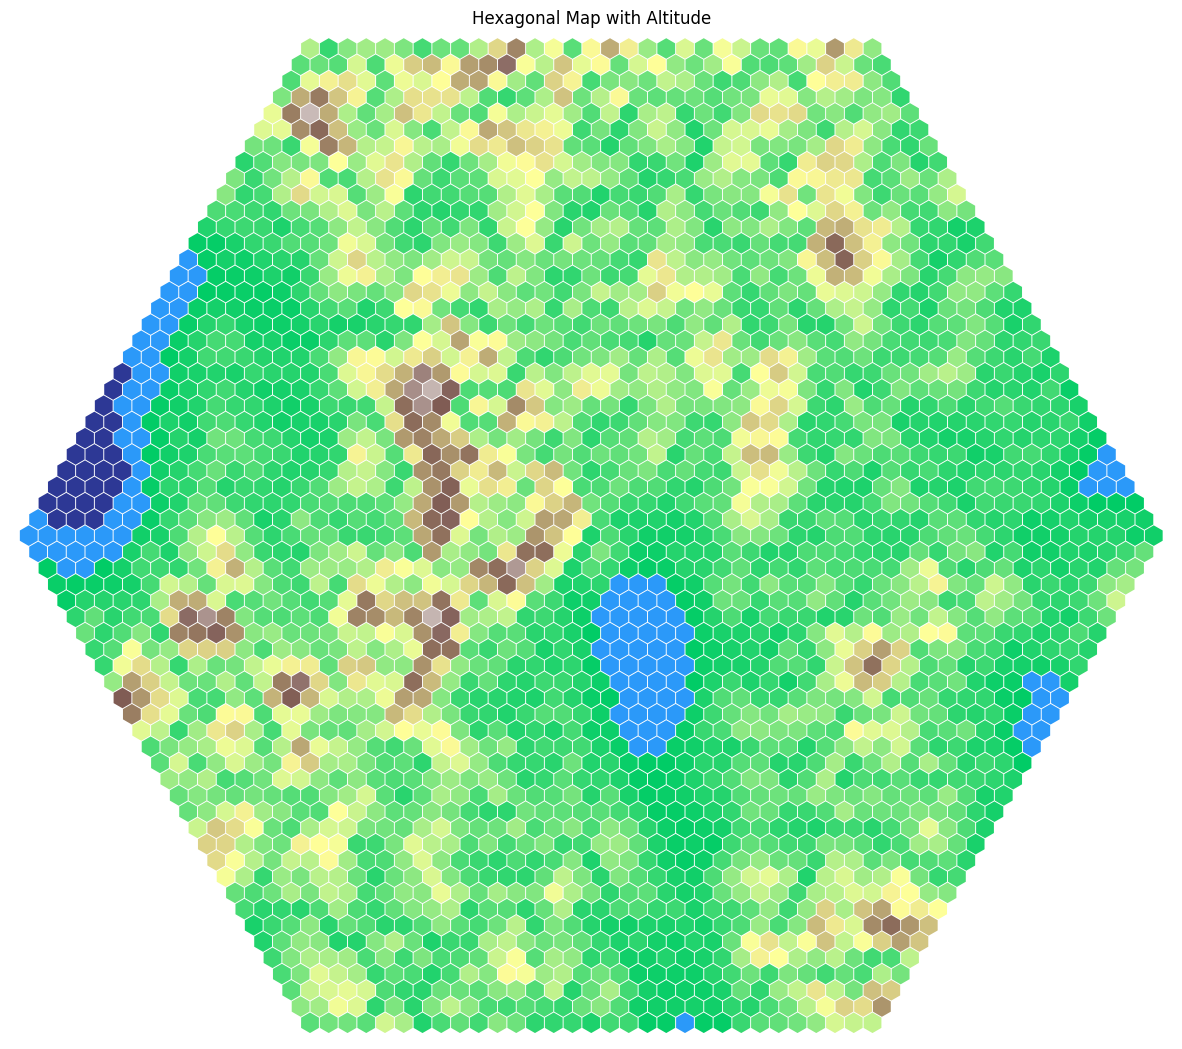

In [6]:
"""Generate the terrain"""

hexmap = map_generation.generate_map()

fig, ax = plt.subplots(figsize=(15, 15))
        
for tile in hexmap:
    x, y = tile.square_coordinates()
    hexagon = RegularPolygon(
        (x, y), numVertices=6, radius=1*0.95,  # 0.95 for spacing
        facecolor=get_tile_color(tile),
    )
    ax.add_patch(hexagon)
    #ax.text(x, y+0.2, str(tile.basin),
    #    ha='center', va='center',  # center horizontally and vertically
    #    fontsize=12, color='black')  # you can adjust fontsize and color
    #ax.text(x, y-0.3, int(tile.altitude),
    #    ha='center', va='center',  # center horizontally and vertically
    #    fontsize=8, color='black')  # you can adjust fontsize and color

ax.set_xlim(-np.sqrt(3) * (map_radius + 1), np.sqrt(3) * (map_radius + 1))
ax.set_ylim(-1.5 * (map_radius + 1), 1.5 * (map_radius + 1))
ax.set_aspect('equal')
ax.axis('off')

plt.title('Hexagonal Map with Altitude')
plt.show()

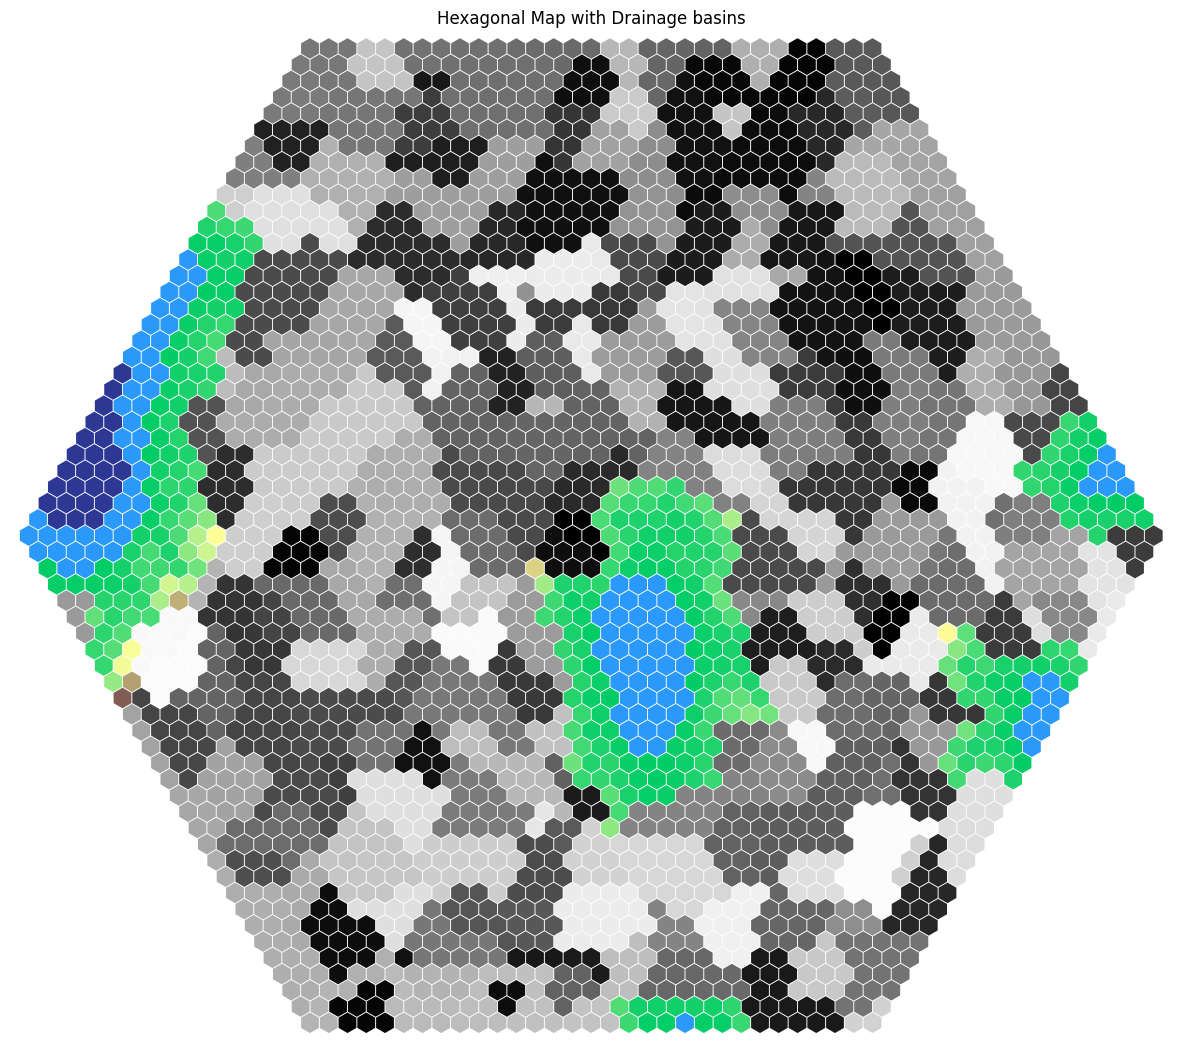

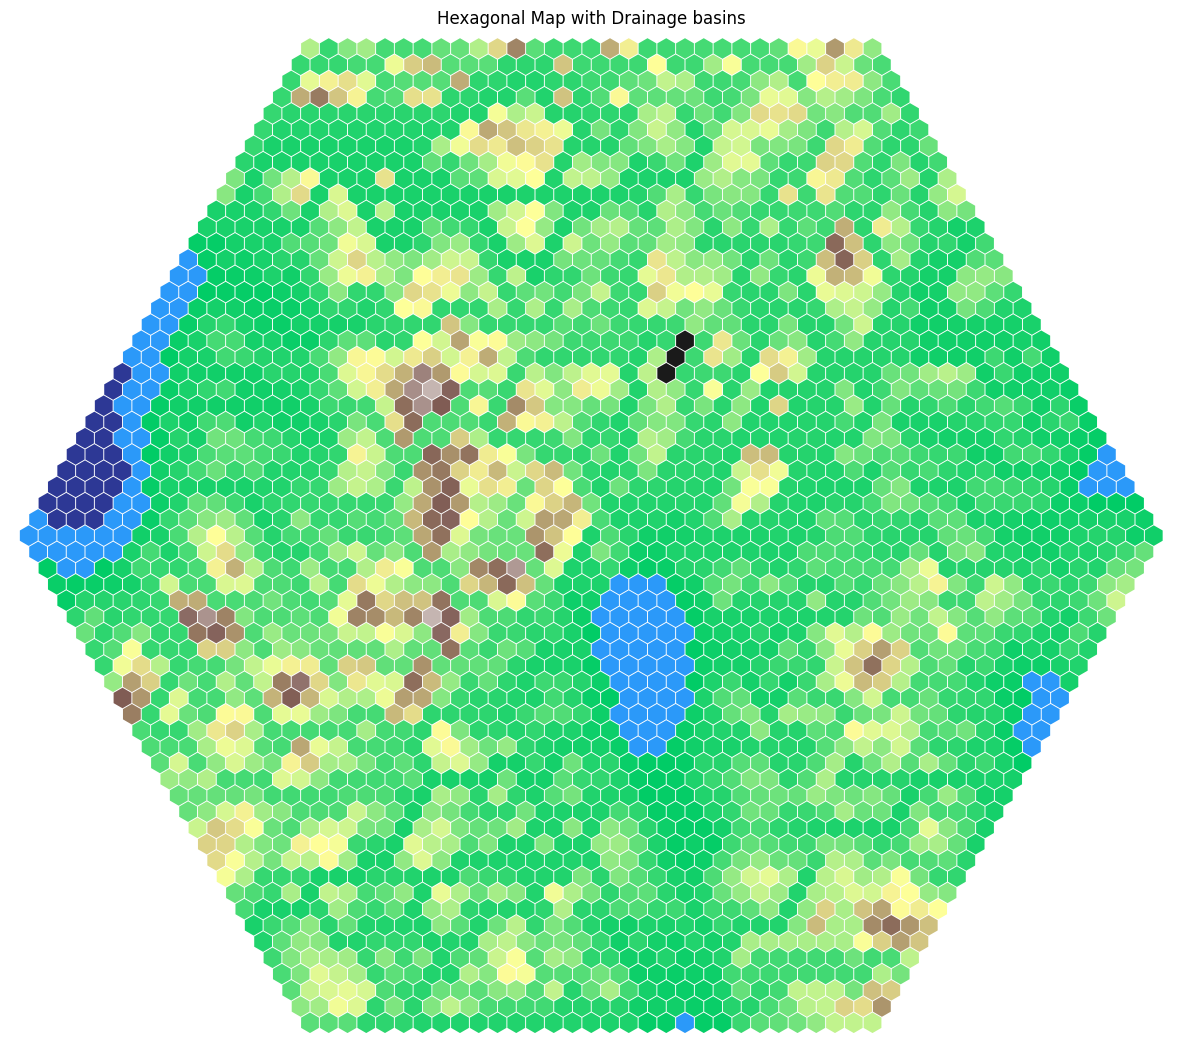

In [7]:
"""Detect and fix basins"""
map_generation.check_for_basins(hexmap)

fig, ax = plt.subplots(figsize=(15, 15))
        
for tile in hexmap:
    x, y = tile.square_coordinates()
    hexagon = RegularPolygon(
        (x, y), numVertices=6, radius=1*0.95,  # 0.95 for spacing
        facecolor=get_tile_color(tile, basin=True),
    )
    ax.add_patch(hexagon)

ax.set_xlim(-np.sqrt(3) * (map_radius + 1), np.sqrt(3) * (map_radius + 1))
ax.set_ylim(-1.5 * (map_radius + 1), 1.5 * (map_radius + 1))
ax.set_aspect('equal')
ax.axis('off')

plt.title('Hexagonal Map with Drainage basins')
plt.show()

map_generation.fix_basins(hexmap)
map_generation.check_for_basins(hexmap)

fig, ax = plt.subplots(figsize=(15, 15))

for tile in hexmap:
    x, y = tile.square_coordinates()
    hexagon = RegularPolygon(
        (x, y), numVertices=6, radius=1*0.95,  # 0.95 for spacing
        facecolor=get_tile_color(tile, basin=True),
    )
    ax.add_patch(hexagon)

ax.set_xlim(-np.sqrt(3) * (map_radius + 1), np.sqrt(3) * (map_radius + 1))
ax.set_ylim(-1.5 * (map_radius + 1), 1.5 * (map_radius + 1))
ax.set_aspect('equal')
ax.axis('off')

plt.title('Hexagonal Map after basin removal')
plt.show()

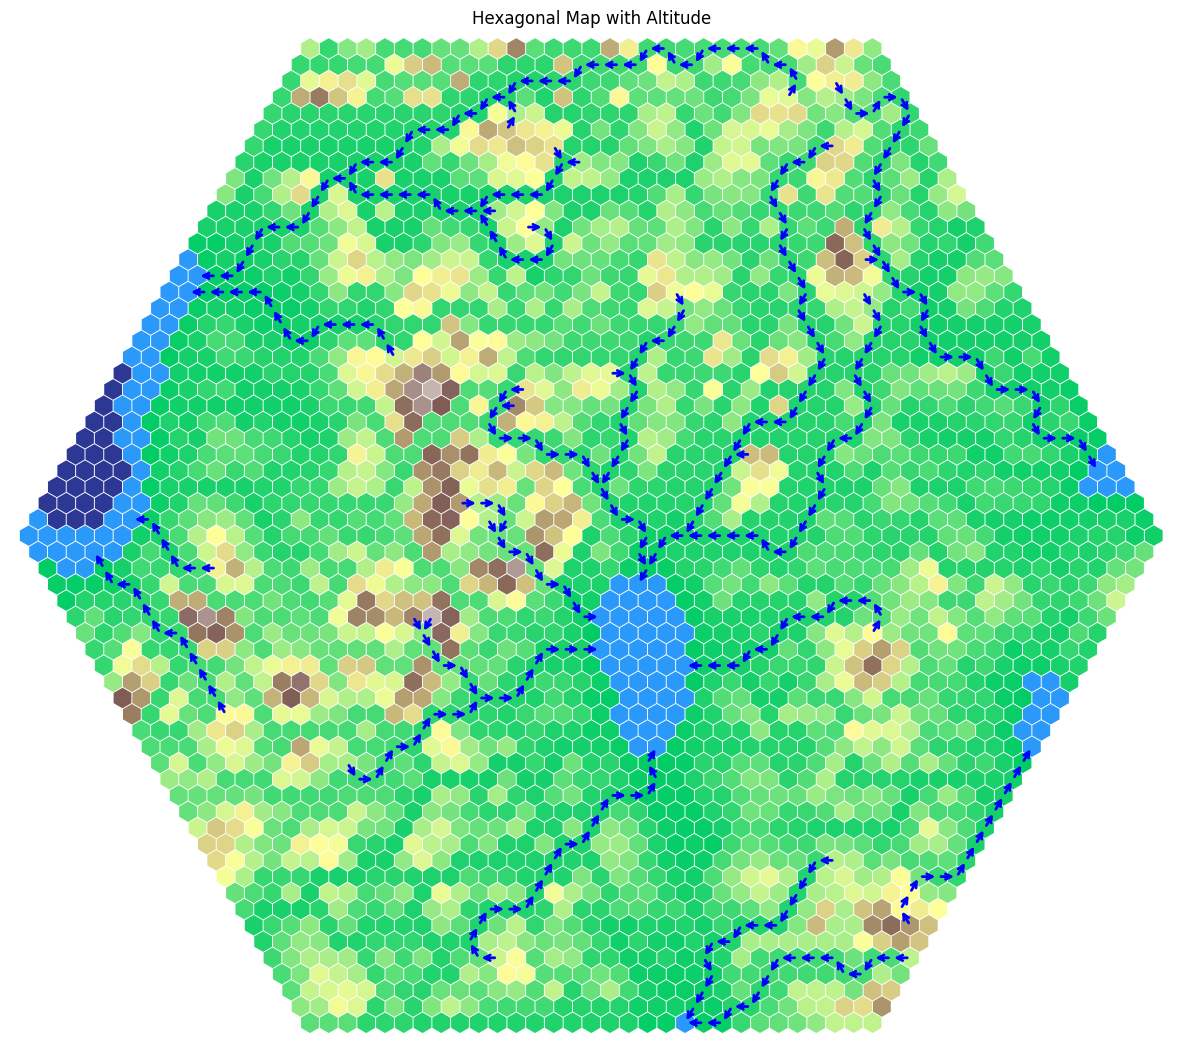

In [8]:
"""Generate rivers"""
map_generation.generate_rivers(hexmap)

fig, ax = plt.subplots(figsize=(15, 15))
        
for tile in hexmap:
    x, y = tile.square_coordinates()
    hexagon = RegularPolygon(
        (x, y), numVertices=6, radius=1*0.95,  # 0.95 for spacing
        facecolor=get_tile_color(tile),
    )
    ax.add_patch(hexagon)

for tile in hexmap:
    if tile.hydro != 0:
        lowest_neighbour = None
        for neighbor in tile.get_neighbors(hexmap):
            if neighbor.hydro != 0 and tile.hydro < neighbor.hydro or neighbor.altitude < 0:
                if lowest_neighbour is None or neighbor.altitude < lowest_neighbour.altitude:
                    lowest_neighbour = neighbor
        # Draw a line between tile and neighbor
        x0, y0 = tile.square_coordinates()
        x1, y1 = lowest_neighbour.square_coordinates()
        ax.annotate("",
            xy=(x1, y1), xytext=(x0, y0),
            arrowprops=dict(arrowstyle="->", color='blue', linewidth=2),
            annotation_clip=False
        )

ax.set_xlim(-np.sqrt(3) * (map_radius + 1), np.sqrt(3) * (map_radius + 1))
ax.set_ylim(-1.5 * (map_radius + 1), 1.5 * (map_radius + 1))
ax.set_aspect('equal')
ax.axis('off')

plt.title('Hexagonal Map with Rivers')
plt.show()